# Mental Health in Technology — Exploratory Data Analysis

### Project: Mental Health in Tech Survey

**Objective:**  
To explore mental health treatment patterns among employees in the technology workplace and identify relationships between treatment, workplace conditions, employee attitudes, and support systems.

---

### Dataset
Mental Health in Tech Survey

### Analysis Type
Exploratory Data Analysis (EDA)

### Key Areas
- Data Cleaning
- Missing Value Analysis
- Treatment Analysis
- Workplace Factors
- Employee Attitudes
- Age and Country Analysis
- Business Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/mental_health.csv")

df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [3]:
df.shape

(1259, 27)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [7]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
comments,1095,86.973789
state,515,40.905481
work_interfere,264,20.969023
self_employed,18,1.429706
Gender,0,0.000000
Timestamp,0,0.000000
Age,0,0.000000
family_history,0,0.000000
treatment,0,0.000000
no_employees,0,0.000000


In [8]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='str')

In [10]:
df.dtypes

Timestamp                      str
Age                          int64
Gender                         str
Country                        str
state                          str
self_employed                  str
family_history                 str
treatment                      str
work_interfere                 str
no_employees                   str
remote_work                    str
tech_company                   str
benefits                       str
care_options                   str
wellness_program               str
seek_help                      str
anonymity                      str
leave                          str
mental_health_consequence      str
phys_health_consequence        str
coworkers                      str
supervisor                     str
mental_health_interview        str
phys_health_interview          str
mental_vs_physical             str
obs_consequence                str
comments                       str
dtype: object

In [11]:
df["Age"].describe()

count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64

In [12]:
df["Age"].value_counts().sort_index()

Age
-1726            1
-29              1
-1               1
 5               1
 8               1
 11              1
 18              7
 19              9
 20              6
 21             16
 22             21
 23             51
 24             46
 25             61
 26             75
 27             71
 28             68
 29             85
 30             63
 31             67
 32             82
 33             70
 34             65
 35             55
 36             37
 37             43
 38             39
 39             33
 40             33
 41             21
 42             20
 43             28
 44             11
 45             12
 46             12
 47              2
 48              6
 49              4
 50              6
 51              5
 53              1
 54              3
 55              3
 56              4
 57              3
 58              1
 60              2
 61              1
 62              1
 65              1
 72              1
 329             1
 9999999

In [13]:
df["Gender"].value_counts(dropna=False)

Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Woman                                               3
Male                                                3
Cis Male                                            2
Female                                              2
Man                                                 2
Female (trans)                                      2
Male-ish                                            1
maile                                               1
Trans-female                                        1
Cis Female           

In [14]:
df["Country"].value_counts()

Country
United States             751
United Kingdom            185
Canada                     72
Germany                    45
Netherlands                27
Ireland                    27
Australia                  21
France                     13
India                      10
New Zealand                 8
Switzerland                 7
Poland                      7
Italy                       7
Sweden                      7
Brazil                      6
South Africa                6
Belgium                     6
Israel                      5
Bulgaria                    4
Singapore                   4
Russia                      3
Mexico                      3
Austria                     3
Finland                     3
Portugal                    2
Colombia                    2
Croatia                     2
Denmark                     2
Greece                      2
Slovenia                    1
Costa Rica                  1
Latvia                      1
Romania                     1
Zi

In [15]:
df["family_history"].value_counts(dropna=False)

family_history
No     767
Yes    492
Name: count, dtype: int64

In [16]:
df["treatment"].value_counts(dropna=False)

treatment
Yes    637
No     622
Name: count, dtype: int64

In [17]:
df["work_interfere"].value_counts(dropna=False)

work_interfere
Sometimes    465
NaN          264
Never        213
Rarely       173
Often        144
Name: count, dtype: int64

In [18]:
df["no_employees"].value_counts(dropna=False)

no_employees
6-25              290
26-100            289
More than 1000    282
100-500           176
1-5               162
500-1000           60
Name: count, dtype: int64

In [19]:
df["remote_work"].value_counts(dropna=False)

remote_work
No     883
Yes    376
Name: count, dtype: int64

In [20]:
df["tech_company"].value_counts(dropna=False)

tech_company
Yes    1031
No      228
Name: count, dtype: int64

In [21]:
df["benefits"].value_counts(dropna=False)

benefits
Yes           477
Don't know    408
No            374
Name: count, dtype: int64

In [22]:
df["care_options"].value_counts(dropna=False)

care_options
No          501
Yes         444
Not sure    314
Name: count, dtype: int64

In [23]:
df["wellness_program"].value_counts(dropna=False)

wellness_program
No            842
Yes           229
Don't know    188
Name: count, dtype: int64

In [24]:
df["seek_help"].value_counts(dropna=False)

seek_help
No            646
Don't know    363
Yes           250
Name: count, dtype: int64

In [25]:
df["anonymity"].value_counts(dropna=False)

anonymity
Don't know    819
Yes           375
No             65
Name: count, dtype: int64

In [26]:
df["leave"].value_counts(dropna=False)

leave
Don't know            563
Somewhat easy         266
Very easy             206
Somewhat difficult    126
Very difficult         98
Name: count, dtype: int64

In [27]:
df["mental_health_consequence"].value_counts(dropna=False)

mental_health_consequence
No       490
Maybe    477
Yes      292
Name: count, dtype: int64

In [28]:
df["phys_health_consequence"].value_counts(dropna=False)

phys_health_consequence
No       925
Maybe    273
Yes       61
Name: count, dtype: int64

In [29]:
df["coworkers"].value_counts(dropna=False)

coworkers
Some of them    774
No              260
Yes             225
Name: count, dtype: int64

In [30]:
df["supervisor"].value_counts(dropna=False)

supervisor
Yes             516
No              393
Some of them    350
Name: count, dtype: int64

In [31]:
df["mental_health_interview"].value_counts(dropna=False)

mental_health_interview
No       1008
Maybe     207
Yes        44
Name: count, dtype: int64

In [32]:
df["phys_health_interview"].value_counts(dropna=False)

phys_health_interview
Maybe    557
No       500
Yes      202
Name: count, dtype: int64

In [33]:
df["mental_vs_physical"].value_counts(dropna=False)

mental_vs_physical
Don't know    576
Yes           343
No            340
Name: count, dtype: int64

In [34]:
df["obs_consequence"].value_counts(dropna=False)

obs_consequence
No     1075
Yes     184
Name: count, dtype: int64

In [35]:
clean_df = df.copy()

clean_df.shape

(1259, 27)

In [36]:
clean_df[~clean_df["Age"].between(18, 100)][["Age"]]

,Age
143,-29
364,329
390,99999999999
715,-1726
734,5
989,8
1090,11
1127,-1


In [37]:
clean_df["Age"] = pd.to_numeric(clean_df["Age"], errors="coerce")

clean_df = clean_df[clean_df["Age"].between(18, 100)].copy()

clean_df.shape

(1251, 27)

In [38]:
clean_df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         513
self_employed                  18
family_history                  0
treatment                       0
work_interfere                262
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1090
dtype: int64

In [39]:
clean_df["self_employed"] = clean_df["self_employed"].fillna("Unknown")

clean_df["self_employed"].value_counts(dropna=False)

self_employed
No         1091
Yes         142
Unknown      18
Name: count, dtype: int64

In [40]:
clean_df["work_interfere"] = clean_df["work_interfere"].fillna("Unknown")

clean_df["work_interfere"].value_counts(dropna=False)

work_interfere
Sometimes    464
Unknown      262
Never        212
Rarely       173
Often        140
Name: count, dtype: int64

In [41]:
clean_df[["self_employed", "work_interfere"]].isnull().sum()

self_employed     0
work_interfere    0
dtype: int64

In [42]:
clean_df["Age_Group"] = pd.cut(
    clean_df["Age"],
    bins=[17, 25, 35, 45, 55, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"]
)

clean_df["Age_Group"].value_counts().sort_index()

Age_Group
18-25    217
26-35    701
36-45    277
46-55     42
56+       14
Name: count, dtype: int64

In [43]:
clean_df.shape

(1251, 28)

In [44]:
clean_df.to_csv("../data/cleaned_mental_health.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


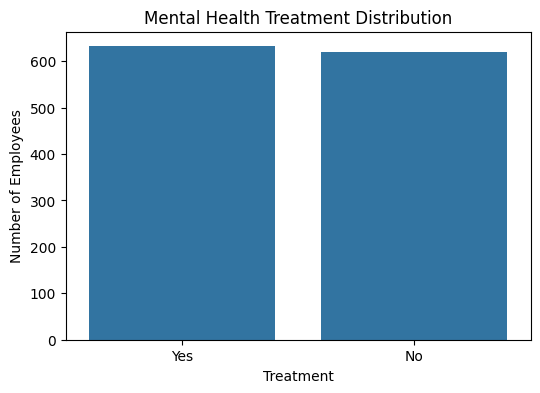

In [45]:
plt.figure(figsize=(6, 4))

sns.countplot(data=clean_df, x="treatment")

plt.title("Mental Health Treatment Distribution")
plt.xlabel("Treatment")
plt.ylabel("Number of Employees")

plt.show()

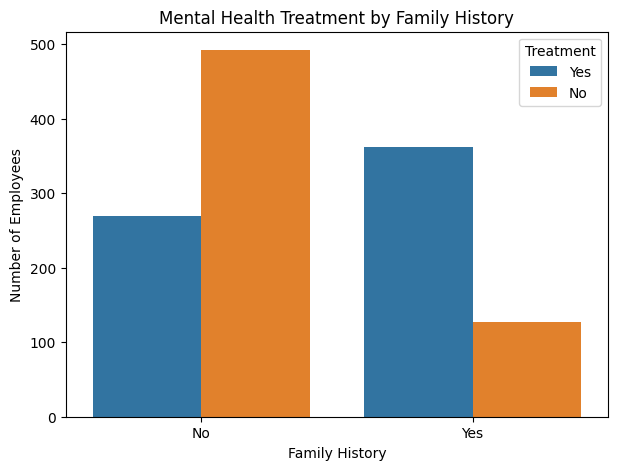

In [46]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=clean_df,
    x="family_history",
    hue="treatment"
)

plt.title("Mental Health Treatment by Family History")
plt.xlabel("Family History")
plt.ylabel("Number of Employees")
plt.legend(title="Treatment")

plt.show()

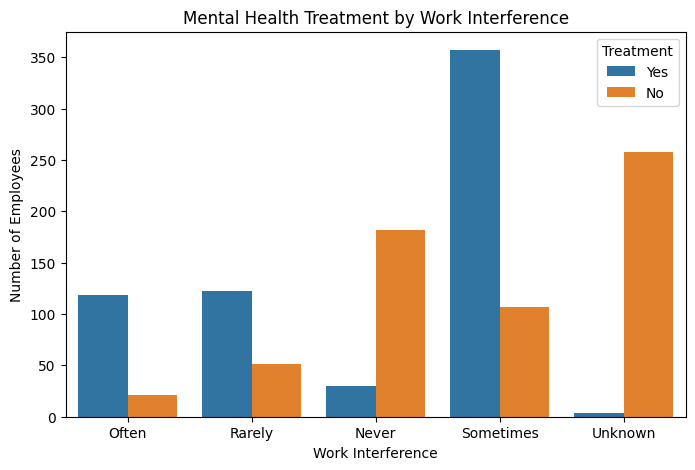

In [47]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="work_interfere",
    hue="treatment"
)

plt.title("Mental Health Treatment by Work Interference")
plt.xlabel("Work Interference")
plt.ylabel("Number of Employees")
plt.legend(title="Treatment")

plt.show()

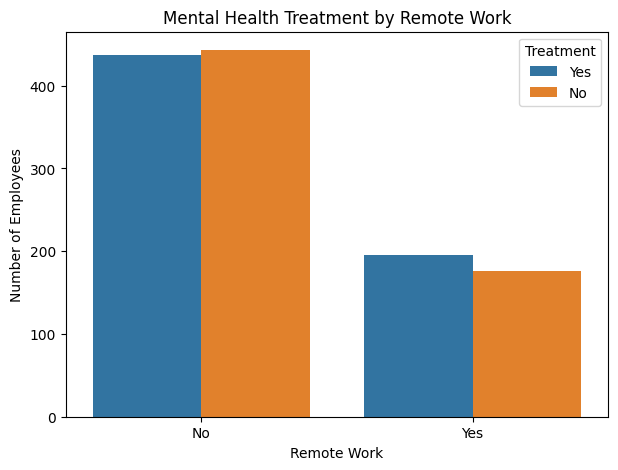

In [48]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=clean_df,
    x="remote_work",
    hue="treatment"
)

plt.title("Mental Health Treatment by Remote Work")
plt.xlabel("Remote Work")
plt.ylabel("Number of Employees")
plt.legend(title="Treatment")

plt.show()

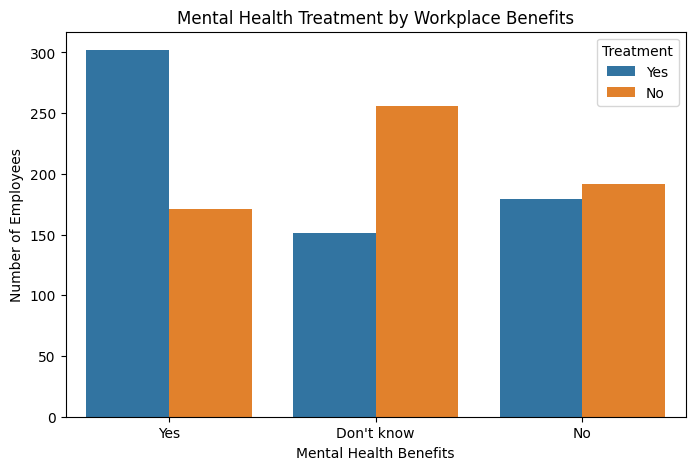

In [49]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="benefits",
    hue="treatment"
)

plt.title("Mental Health Treatment by Workplace Benefits")
plt.xlabel("Mental Health Benefits")
plt.ylabel("Number of Employees")
plt.legend(title="Treatment")

plt.show()

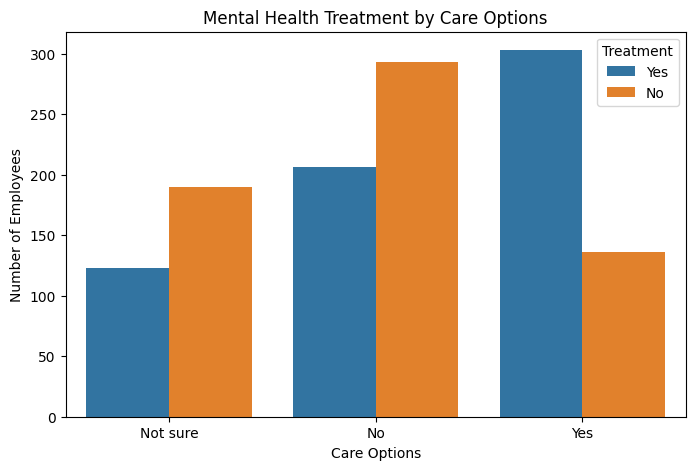

In [50]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="care_options",
    hue="treatment"
)

plt.title("Mental Health Treatment by Care Options")
plt.xlabel("Care Options")
plt.ylabel("Number of Employees")
plt.legend(title="Treatment")

plt.show()

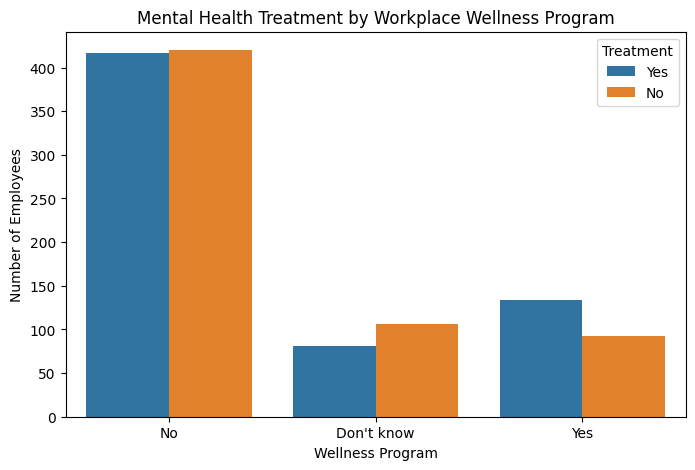

In [51]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="wellness_program",
    hue="treatment"
)

plt.title("Mental Health Treatment by Workplace Wellness Program")
plt.xlabel("Wellness Program")
plt.ylabel("Number of Employees")
plt.legend(title="Treatment")

plt.show()

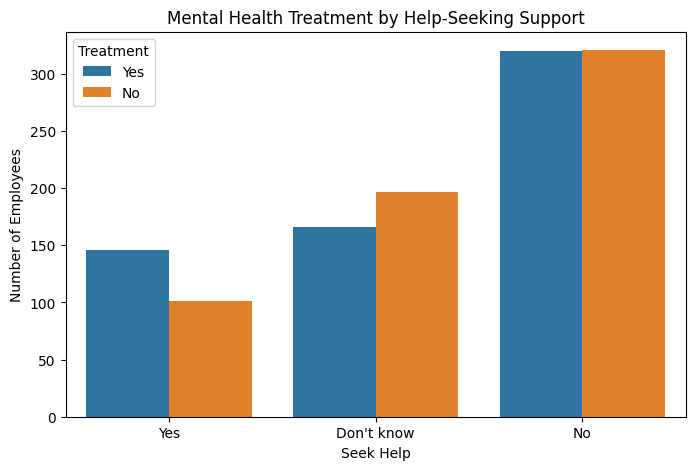

In [52]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="seek_help",
    hue="treatment"
)

plt.title("Mental Health Treatment by Help-Seeking Support")
plt.xlabel("Seek Help")
plt.ylabel("Number of Employees")
plt.legend(title="Treatment")

plt.show()

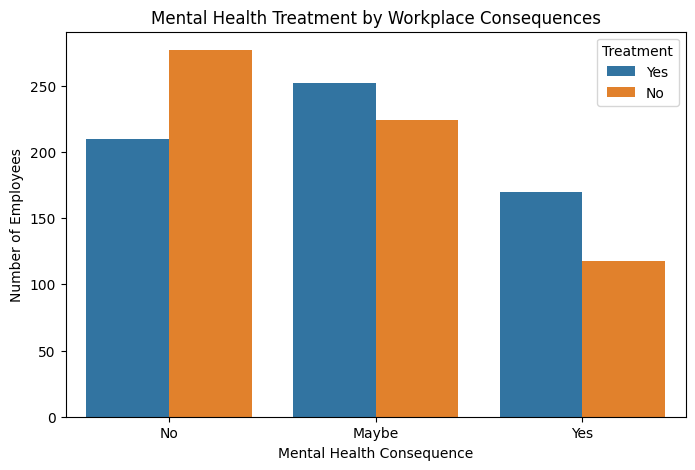

In [53]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="mental_health_consequence",
    hue="treatment"
)

plt.title("Mental Health Treatment by Workplace Consequences")
plt.xlabel("Mental Health Consequence")
plt.ylabel("Number of Employees")
plt.legend(title="Treatment")

plt.show()

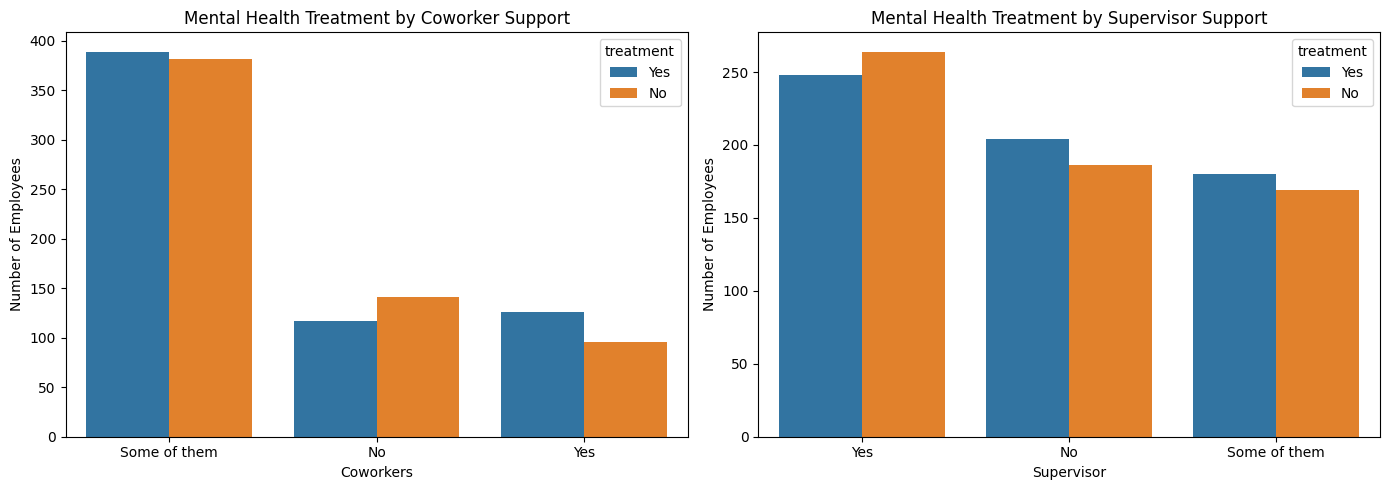

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=clean_df,
    x="coworkers",
    hue="treatment",
    ax=axes[0]
)

axes[0].set_title("Mental Health Treatment by Coworker Support")
axes[0].set_xlabel("Coworkers")
axes[0].set_ylabel("Number of Employees")

sns.countplot(
    data=clean_df,
    x="supervisor",
    hue="treatment",
    ax=axes[1]
)

axes[1].set_title("Mental Health Treatment by Supervisor Support")
axes[1].set_xlabel("Supervisor")
axes[1].set_ylabel("Number of Employees")

plt.tight_layout()
plt.show()

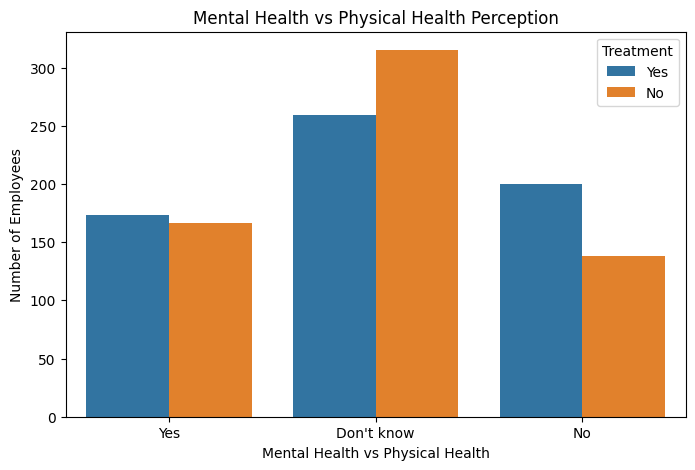

In [55]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="mental_vs_physical",
    hue="treatment"
)

plt.title("Mental Health vs Physical Health Perception")
plt.xlabel("Mental Health vs Physical Health")
plt.ylabel("Number of Employees")
plt.legend(title="Treatment")

plt.show()

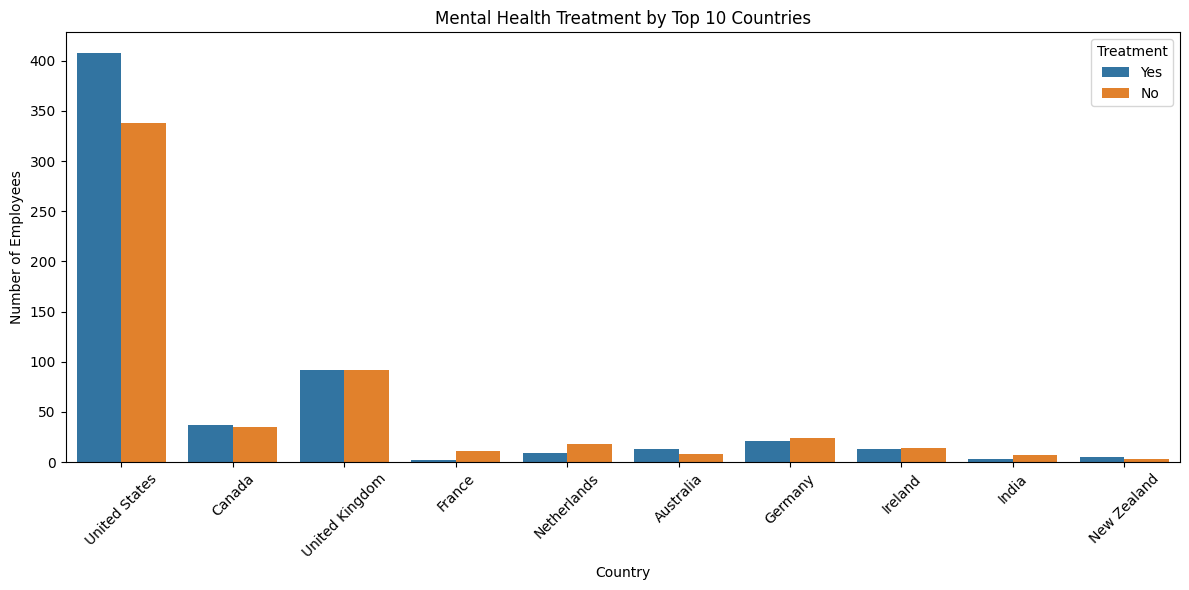

In [56]:
top_countries = clean_df["Country"].value_counts().head(10).index

country_df = clean_df[
    clean_df["Country"].isin(top_countries)
]

plt.figure(figsize=(12, 6))

sns.countplot(
    data=country_df,
    x="Country",
    hue="treatment"
)

plt.title("Mental Health Treatment by Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.legend(title="Treatment")

plt.tight_layout()
plt.show()

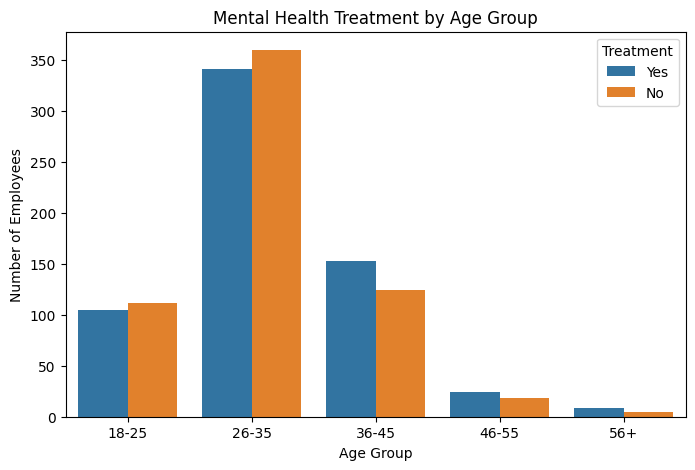

In [57]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="Age_Group",
    hue="treatment"
)

plt.title("Mental Health Treatment by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.legend(title="Treatment")

plt.show()

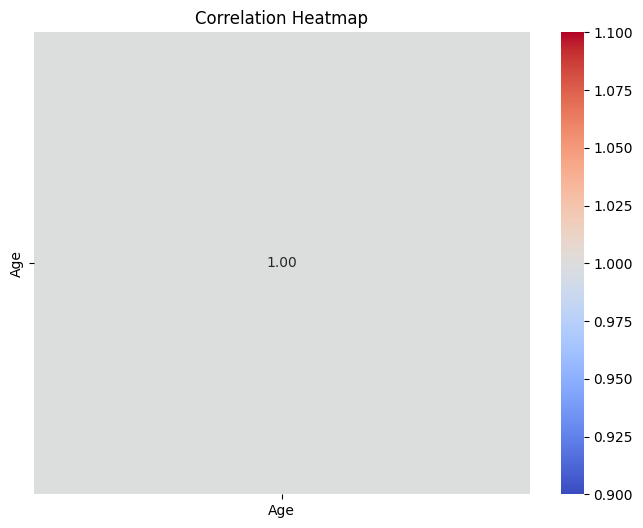

In [58]:
numeric_df = clean_df.select_dtypes(include=np.number)

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

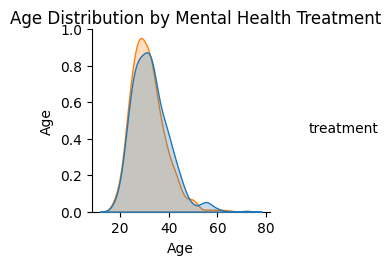

In [59]:
sns.pairplot(
    clean_df,
    vars=["Age"],
    hue="treatment"
)

plt.suptitle(
    "Age Distribution by Mental Health Treatment",
    y=1.02
)

plt.show()

In [60]:
print("Final Dataset Shape:", clean_df.shape)
print("\nTotal Missing Values:")
print(clean_df.isnull().sum().sum())

print("\nTotal Duplicate Rows:")
print(clean_df.duplicated().sum())

Final Dataset Shape: (1251, 28)

Total Missing Values:
1603

Total Duplicate Rows:
0


In [61]:
treatment_counts = clean_df["treatment"].value_counts()

treatment_percentage = (
    clean_df["treatment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

treatment_summary = pd.DataFrame({
    "Count": treatment_counts,
    "Percentage": treatment_percentage
})

treatment_summary

,Count,Percentage
treatment,,
Yes,632,50.52
No,619,49.48


In [62]:
family_treatment = pd.crosstab(
    clean_df["family_history"],
    clean_df["treatment"],
    normalize="index"
) * 100

family_treatment.round(2)

treatment,No,Yes
family_history,,
No,64.57,35.43
Yes,25.97,74.03


In [63]:
work_treatment = pd.crosstab(
    clean_df["work_interfere"],
    clean_df["treatment"],
    normalize="index"
) * 100

work_treatment.round(2)

treatment,No,Yes
work_interfere,,
Never,85.85,14.15
Often,15.00,85.00
Rarely,29.48,70.52
Sometimes,23.06,76.94
Unknown,98.47,1.53


In [64]:
remote_treatment = pd.crosstab(
    clean_df["remote_work"],
    clean_df["treatment"],
    normalize="index"
) * 100

remote_treatment.round(2)

treatment,No,Yes
remote_work,,
No,50.34,49.66
Yes,47.44,52.56


In [65]:
benefits_treatment = pd.crosstab(
    clean_df["benefits"],
    clean_df["treatment"],
    normalize="index"
) * 100

benefits_treatment.round(2)

treatment,No,Yes
benefits,,
Don't know,62.90,37.10
No,51.75,48.25
Yes,36.15,63.85


In [66]:
care_treatment = pd.crosstab(
    clean_df["care_options"],
    clean_df["treatment"],
    normalize="index"
) * 100

care_treatment.round(2)

treatment,No,Yes
care_options,,
No,58.72,41.28
Not sure,60.70,39.30
Yes,30.98,69.02


In [67]:
wellness_treatment = pd.crosstab(
    clean_df["wellness_program"],
    clean_df["treatment"],
    normalize="index"
) * 100

wellness_treatment.round(2)

treatment,No,Yes
wellness_program,,
Don't know,56.68,43.32
No,50.18,49.82
Yes,40.97,59.03


In [68]:
seek_help_treatment = pd.crosstab(
    clean_df["seek_help"],
    clean_df["treatment"],
    normalize="index"
) * 100

seek_help_treatment.round(2)

treatment,No,Yes
seek_help,,
Don't know,54.27,45.73
No,50.08,49.92
Yes,40.89,59.11


In [69]:
consequence_treatment = pd.crosstab(
    clean_df["mental_health_consequence"],
    clean_df["treatment"],
    normalize="index"
) * 100

consequence_treatment.round(2)

treatment,No,Yes
mental_health_consequence,,
Maybe,47.06,52.94
No,56.88,43.12
Yes,40.97,59.03


In [70]:
country_treatment = pd.crosstab(
    country_df["Country"],
    country_df["treatment"],
    normalize="index"
) * 100

country_treatment.round(2)

treatment,No,Yes
Country,,
Australia,38.10,61.90
Canada,48.61,51.39
France,84.62,15.38
Germany,53.33,46.67
India,70.00,30.00
Ireland,51.85,48.15
Netherlands,66.67,33.33
New Zealand,37.50,62.50
United Kingdom,50.00,50.00


In [71]:
age_treatment = pd.crosstab(
    clean_df["Age_Group"],
    clean_df["treatment"],
    normalize="index"
) * 100

age_treatment.round(2)

treatment,No,Yes
Age_Group,,
18-25,51.61,48.39
26-35,51.36,48.64
36-45,44.77,55.23
46-55,42.86,57.14
56+,35.71,64.29


In [72]:
summary_tables = {
    "Family History": family_treatment,
    "Work Interference": work_treatment,
    "Remote Work": remote_treatment,
    "Benefits": benefits_treatment,
    "Care Options": care_treatment,
    "Wellness Program": wellness_treatment,
    "Seek Help": seek_help_treatment,
    "Mental Health Consequence": consequence_treatment,
    "Age Group": age_treatment
}

print("EDA treatment analysis tables created successfully.")
print("Total analysis factors:", len(summary_tables))

EDA treatment analysis tables created successfully.
Total analysis factors: 9


In [73]:
age_summary = clean_df["Age"].describe().round(2)

age_summary

count    1251.00
mean       32.08
std         7.29
min        18.00
25%        27.00
50%        31.00
75%        36.00
max        72.00
Name: Age, dtype: float64

In [74]:
print("KEY EDA RESULTS")
print("=" * 50)

print("\n1. Treatment Distribution")
print(treatment_summary)

print("\n2. Family History vs Treatment")
print(family_treatment.round(2))

print("\n3. Work Interference vs Treatment")
print(work_treatment.round(2))

print("\n4. Remote Work vs Treatment")
print(remote_treatment.round(2))

print("\n5. Age Group vs Treatment")
print(age_treatment.round(2))

KEY EDA RESULTS

1. Treatment Distribution
           Count  Percentage
treatment                   
Yes          632       50.52
No           619       49.48

2. Family History vs Treatment
treatment          No    Yes
family_history              
No              64.57  35.43
Yes             25.97  74.03

3. Work Interference vs Treatment
treatment          No    Yes
work_interfere              
Never           85.85  14.15
Often           15.00  85.00
Rarely          29.48  70.52
Sometimes       23.06  76.94
Unknown         98.47   1.53

4. Remote Work vs Treatment
treatment       No    Yes
remote_work              
No           50.34  49.66
Yes          47.44  52.56

5. Age Group vs Treatment
treatment     No    Yes
Age_Group              
18-25      51.61  48.39
26-35      51.36  48.64
36-45      44.77  55.23
46-55      42.86  57.14
56+        35.71  64.29


# EDA Insights

## 1. Treatment Distribution
The treatment distribution provides an overall view of employees who have received mental health treatment. This serves as the baseline for comparing treatment patterns across different workplace and personal factors.

## 2. Family History and Treatment
Employees were compared based on whether they reported a family history of mental health conditions. The treatment percentages help identify differences between employees with and without a family history.

## 3. Work Interference and Treatment
Treatment patterns were analyzed across different levels of work interference. This helps identify whether employees reporting greater interference between mental health and work show different treatment patterns.

## 4. Remote Work and Treatment
Treatment rates were compared between employees who work remotely and those who do not. This helps explore whether work arrangement is associated with mental health treatment patterns.

## 5. Workplace Benefits and Treatment
The analysis compares treatment rates among employees who reported having mental health benefits, not having benefits, or being unsure about them.

## 6. Care Options and Treatment
Treatment patterns were compared based on employees' awareness of available mental health care options.

## 7. Wellness Programs and Treatment
The analysis examines treatment rates across employees who reported the presence, absence, or uncertainty of workplace wellness programs.

## 8. Help-Seeking Support and Treatment
Treatment patterns were compared based on whether employees knew about workplace support for seeking mental health help.

## 9. Workplace Consequences
Employees' perceptions of the consequences of discussing mental health at work were compared with treatment patterns.

## 10. Age Group and Treatment
Treatment rates were compared across different age groups to identify possible age-related patterns in mental health treatment.

## Overall Observation
The EDA examines how mental health treatment patterns vary across personal characteristics, work conditions, workplace support, and employee attitudes. These findings can help identify areas where organizations may strengthen mental health awareness, support, and workplace policies.


# Business Objective

The main objective of this analysis is to understand the factors associated with mental health treatment among employees in the technology workplace.

The analysis focuses on:

- Identifying patterns in mental health treatment.
- Understanding the relationship between family history and treatment.
- Examining how mental health interferes with work.
- Comparing treatment patterns across remote and non-remote employees.
- Understanding the role of workplace mental health benefits.
- Examining the availability of care options and wellness programs.
- Understanding employee attitudes toward seeking mental health support.
- Comparing treatment patterns across different age groups and countries.

## Business Value

The findings can help technology organizations identify areas where mental health support can be improved. Organizations can use these insights to strengthen awareness programs, improve access to mental health resources, and create a more supportive workplace environment.

## Decision Support

The analysis provides data-driven evidence that can help organizations understand employee mental health needs and make better decisions regarding workplace mental health initiatives.

# Solution to Business Objective

Based on the exploratory analysis, organizations can use employee survey data to identify patterns associated with mental health treatment and workplace experiences.

## Recommended Actions

1. **Improve Mental Health Awareness**
   - Conduct regular awareness sessions about mental health.
   - Reduce misconceptions and stigma around mental health support.

2. **Improve Access to Mental Health Resources**
   - Clearly communicate available care options and support services.
   - Make mental health resources easy for employees to access.

3. **Strengthen Workplace Wellness Programs**
   - Provide effective mental health and wellness initiatives.
   - Ensure employees are aware of the programs available to them.

4. **Create a Supportive Work Environment**
   - Encourage employees to discuss mental health concerns without fear of negative consequences.
   - Promote supportive relationships between employees, coworkers, and supervisors.

5. **Monitor Work-Related Mental Health Challenges**
   - Pay attention to employees reporting that mental health interferes with their work.
   - Use appropriate support programs to help employees manage workplace challenges.

6. **Use Data for Continuous Improvement**
   - Conduct employee surveys regularly.
   - Track changes in treatment patterns and workplace attitudes over time.

## Expected Business Benefit

These actions can help organizations create a more supportive workplace, improve awareness of available mental health resources, and make workplace mental health initiatives more data-driven.

# Conclusion

This project explored the Mental Health in Technology survey dataset to understand patterns related to mental health treatment among employees.

The analysis included data cleaning, missing-value handling, age validation, age-group creation, descriptive analysis, and multiple visualizations.

The EDA examined the relationship between mental health treatment and factors such as:

- Family history
- Work interference
- Remote work
- Workplace benefits
- Care options
- Wellness programs
- Help-seeking support
- Workplace consequences
- Age groups
- Countries

The analysis provides a data-driven view of employee mental health experiences in technology workplaces.

Overall, the findings can help organizations identify areas where mental health awareness, accessibility of support, employee communication, and workplace wellness initiatives can be strengthened.

The results of this exploratory analysis can serve as a foundation for making more informed workplace mental health decisions.